In [2]:
!pip install unsloth trl transformers datasets matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/21

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
path = "/content/drive/MyDrive/fin-research-agent/finetune/train.jsonl"
print(os.path.exists(path))  # should print True

True


In [5]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 6144

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-3B-Instruct",
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.22: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0,
    bias="none",
)

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.8.22 patched 36 layers with 36 QKV layers, 36 O layers and 0 MLP layers.


In [7]:
from google.colab import files
uploaded = files.upload()   # select train.jsonl and val.jsonl together

Saving train.jsonl to train.jsonl
Saving val.jsonl to val.jsonl


In [8]:
def format_example(row):
    row["text"] = (
        f"### Instruction:\n{row['instruction']}\n\n"
        f"### Input:\n{row['input']}\n\n"
        f"### Response:\n{row['output']}"
    )
    return row

In [9]:
from datasets import load_dataset

train_dataset = load_dataset("json", data_files="train.jsonl", split="train").map(format_example)
val_dataset = load_dataset("json", data_files="val.jsonl", split="train").map(format_example)

print(f"Train rows: {len(train_dataset)}, Val rows: {len(val_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/162 [00:00<?, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/29 [00:00<?, ? examples/s]

Train rows: 162, Val rows: 29


In [10]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    learning_rate=2e-4,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    output_dir="outputs_day28",
    report_to="none",
)


In [11]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    args=training_args,
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/162 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/29 [00:00<?, ? examples/s]

In [12]:
train_result = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 162 | Num Epochs = 4 | Total steps = 84
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 7,372,800 of 3,093,311,488 (0.24% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,1.681755,1.377885
2,0.979921,0.938451
3,0.887810,0.919555
4,0.899145,0.914831


Unsloth: Restored added_tokens_decoder metadata in outputs_day28/checkpoint-21/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_day28/checkpoint-42/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_day28/checkpoint-63/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_day28/checkpoint-84/tokenizer_config.json.


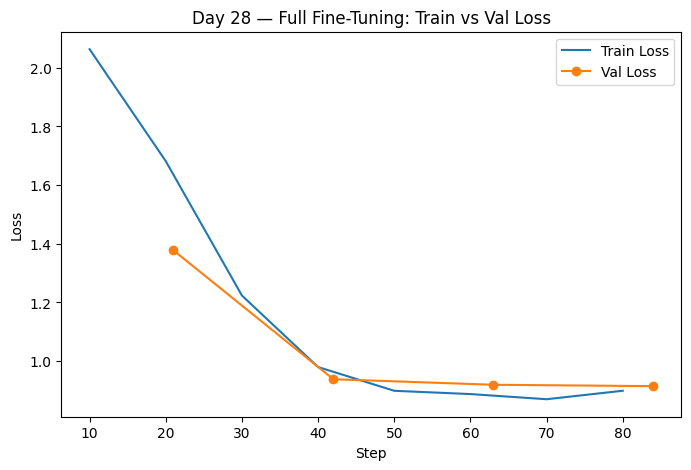

In [13]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_losses = [(h["step"], h["loss"]) for h in history if "loss" in h]
val_losses = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]

plt.figure(figsize=(8, 5))
plt.plot(*zip(*train_losses), label="Train Loss")
plt.plot(*zip(*val_losses), label="Val Loss", marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Day 28 — Full Fine-Tuning: Train vs Val Loss")
plt.legend()
plt.savefig("day28_loss_curve.png")
plt.show()

In [14]:
model.save_pretrained("full_adapter_v1")
tokenizer.save_pretrained("full_adapter_v1")

import shutil, os
os.makedirs("/content/drive/MyDrive/fin-research-agent/adapters", exist_ok=True)
shutil.copytree("full_adapter_v1", "/content/drive/MyDrive/fin-research-agent/adapters/full_adapter_v1", dirs_exist_ok=True)

Unsloth: Restored added_tokens_decoder metadata in full_adapter_v1/tokenizer_config.json.


'/content/drive/MyDrive/fin-research-agent/adapters/full_adapter_v1'

In [15]:
import shutil
shutil.make_archive("full_adapter_v1", 'zip', "full_adapter_v1")
files.download("full_adapter_v1.zip")
files.download("day28_loss_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>